# Dashboard - TranxMex Analisis y Optimizacion Finanaciera

---

**Fecha de creación:** Julio 2026

**Autor:** David Alexander Pupo González

### Tabla de contenido

---

1. Importar librerías y definir entorno
2. Cargar y validar datos
3. KPIs ejecutivos
4. Evolución temporal
5. Categorías clave
6. Canales de pago
7. Clientes 80/20
8. Centros de coste
9. Dashboard visual
10. Recomendaciones automáticas
11. Exportar dashboard a HTML


### Propósito del proyecto

---

En esta sección se construye un dashboard financiero a partir de transacciones_limpias.csv. El objetivo es visualizar los patrones más importantes del proyecto: qué estado domina, dónde se concentra la actividad, qué categorías pesan más, cómo se distribuye por país y canal, y si existe comportamiento temporal relevante.


### 1. Importar librerías y definir entorno

Aquí se cargan las bibliotecas necesarias para análisis, gráficos y manejo de rutas. También se define la carpeta de salida donde se guardarán los archivos del dashboard.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

out = Path("output")
out.mkdir(exist_ok=True)


**Descripción:**

- ```pandas``` se usa para trabajar con tablas y hacer agrupaciones.
- ```numpy``` ayuda con valores nulos y operaciones numéricas.
- ```matplotlib.pyplot``` sirve para generar gráficos.
- ```seaborn``` aporta una estética más profesional.
- ```Path``` permite manejar rutas de archivos de forma clara.
- ```warnings.filterwarnings('ignore')``` oculta avisos que no aportan al análisis.
- ```plt.style.use(...)``` aplica un estilo visual limpio.
- ```out = Path("output")``` define la carpeta de salida.
- ```out.mkdir(exist_ok=True)``` crea la carpeta si no existe.


### 2. Cargar y validar datos

Esta celda carga el archivo limpio y verifica que el dataset esté listo para el análisis ejecutivo.


In [2]:
print("1. CARGA Y VALIDACIÓN")
df = pd.read_csv(out / "transacciones_limpias.csv")

print(f"Dataset cargado: {len(df):,} filas, {df.shape[1]} columnas")
print(f"Rango fechas: {df['fecha'].min()} -> {df['fecha'].max()}")
print(f"Total transacciones: €{df['importe_limpio'].sum():,.0f}")

df['fecha'] = pd.to_datetime(df['fecha'], errors='coerce')


1. CARGA Y VALIDACIÓN
Dataset cargado: 1,002 filas, 18 columnas
Rango fechas: 2024-01-02 -> 2026-04-30
Total transacciones: €9,707,409


**Descripción:**

- ```pd.read_csv(...)``` carga el archivo limpio.
- ```len(df)``` calcula cuántas filas tiene el dataset.
- ```df.shape[1]``` cuenta las columnas.
- ```df['fecha'].min()``` y ```.max()``` muestran el rango temporal.
- ```df['importe_limpio'].sum()``` calcula el total monetario.
- ```pd.to_datetime(...)``` convierte la columna fecha a formato fecha real para poder analizar por periodos.


### 3. KPIs ejecutivos

Aquí se calculan las métricas más importantes para un dashboard de dirección.


In [3]:
print("2. KPIs GENERALES")

ingresos = df[df['tipo_movimiento'] == 'Ingreso']['importe_limpio'].sum()
gastos = df[df['tipo_movimiento'] == 'Gasto']['importe_limpio'].sum()
saldo = ingresos - gastos
margen = (saldo / ingresos * 100) if ingresos != 0 else 0
pct_pagadas = len(df[df['estado'] == 'Pagado']) / len(df) * 100

kpis = {
    'Total Ingresos': f"€{ingresos:,.0f}",
    'Total Gastos': f"€{gastos:,.0f}",
    'Saldo Neto': f"€{saldo:,.0f}",
    'Margen (%)': f"{margen:.1f}%",
    'Transacciones': f"{len(df):,}",
    'Pagadas (%)': f"{pct_pagadas:.1f}%"
}

for k, v in kpis.items():
    print(f"{k:<15}: {v}")


2. KPIs GENERALES
Total Ingresos : €4,697,876
Total Gastos   : €5,009,533
Saldo Neto     : €-311,658
Margen (%)     : -6.6%
Transacciones  : 1,002
Pagadas (%)    : 70.0%


**Descripción:**

- Se separan ingresos y gastos usando ```tipo_movimiento```.
- ```saldo``` muestra la diferencia entre lo que entra y lo que sale.
- ```margen``` mide qué parte de los ingresos queda como resultado neto.
- ```pct_pagadas``` muestra el peso de operaciones completadas.
- ```kpis``` organiza las métricas en un diccionario para imprimirlas de forma ordenada.


### 4. Evolución temporal

Esta celda resume la evolución mensual y permite detectar tendencia y picos.


In [4]:
print("3. ANÁLISIS TEMPORAL")

temporal = (
    df.groupby(['anio', 'mes', 'nombre_mes'])['importe_limpio']
    .sum()
    .reset_index()
)

temporal['fecha_mes'] = pd.to_datetime(
    temporal['anio'].astype(str) + '-' + temporal['mes'].astype(str) + '-01'
)

temporal = temporal.sort_values('fecha_mes')
temporal['yoy'] = temporal['importe_limpio'].pct_change(12) * 100

print(f"Crecimiento Importe YoY promedio: {temporal['yoy'].mean():.1f}%")
print(f"Mejor mes: {temporal.loc[temporal['importe_limpio'].idxmax(), 'nombre_mes']}")


3. ANÁLISIS TEMPORAL
Crecimiento Importe YoY promedio: 119.1%
Mejor mes: Agosto


**Descripción:**

- ```groupby(['anio', 'mes', 'nombre_mes'])``` agrupa por mes y año.
- ```.sum()``` calcula el importe total por periodo.
- ```fecha_mes``` construye una fecha mensual para poder graficar en orden.
- ```pct_change(12)``` estima el crecimiento interanual.
- Se imprime el crecimiento medio y el mejor mes del periodo.


### 5. Categorías clave

Aquí se identifican las categorías que más aportan ingresos, las que más consumen gasto y la categoría más rentable.


In [5]:
print("4. ANÁLISIS CATEGORÍAS")

cat_ing = (
    df[df['tipo_movimiento'] == 'Ingreso']
    .groupby('categoria')['importe_limpio']
    .sum()
    .sort_values(ascending=False)
)

cat_gas = (
    abs(df[df['tipo_movimiento'] == 'Gasto']
    .groupby('categoria')['importe_limpio']
    .sum())
    .sort_values(ascending=False)
)

roi_cat = (cat_ing / (cat_ing + cat_gas)).sort_values(ascending=False) * 100

print("TOP 3 INGRESOS:")
for i, (cat, val) in enumerate(cat_ing.head(3).items(), 1):
    print(f"{i}. {cat:<15}: €{val:>8,.0f}")

print("TOP 3 GASTOS:")
for i, (cat, val) in enumerate(cat_gas.head(3).items(), 1):
    print(f"{i}. {cat:<15}: €{val:>8,.0f}")

print(f"Categoría más rentable: {roi_cat.index[0]} (ROI {roi_cat.iloc[0]:.0f}%)")


4. ANÁLISIS CATEGORÍAS
TOP 3 INGRESOS:
1. Logística      : € 932,431
2. Suministros    : € 854,356
3. Marketing      : € 615,944
TOP 3 GASTOS:
1. Suministros    : €1,054,818
2. Otros          : € 932,368
3. Financiación   : € 726,247
Categoría más rentable: Marketing (ROI 80%)


**Descripción:**

- ```cat_ing``` suma ingresos por categoría.
- ```cat_gas``` suma gastos por categoría y los convierte en valor absoluto.
- ```roi_cat``` estima la rentabilidad relativa por categoría.
- El bloque de impresión muestra el ranking de ingresos y gastos.
- La primera categoría de ```roi_cat``` es la más rentable.


### 6. Canales de pago

Esta celda analiza qué canal aporta más valor y cuál es más eficiente por transacción.


In [6]:
print("5. EFICIENCIA CANALES")

canal_valor = df.groupby('canal_pago')['importe_limpio'].sum().sort_values(ascending=False)
canal_vol = df['canal_pago'].value_counts()
canal_efic = (canal_valor / canal_vol).sort_values(ascending=False)

for canal, ef in canal_efic.items():
    print(f"{canal:<12}: €{ef:>8,.0f} / transacción")


5. EFICIENCIA CANALES
Bizum       : €  14,667 / transacción
Paypal      : €  12,978 / transacción
Transferencia: €  11,567 / transacción
Efectivo    : €   9,479 / transacción
Tarjeta     : €   4,555 / transacción
SEPA        : €   3,537 / transacción


**Descripción:**

- ```canal_valor``` suma el importe total por canal.
- ```canal_vol``` cuenta cuántas transacciones hay por canal.
- ```canal_efic``` calcula el valor medio por transacción.
- Esto permite detectar canales con más peso económico, no solo con más volumen.


### 7. Clientes 80/20

Aquí se analiza la concentración de ingresos en pocos clientes, útil para identificar riesgo comercial.


In [7]:
print("6. ANÁLISIS CLIENTES")

ingresos_clientes = (
    df[df['tipo_movimiento'] == 'Ingreso']
    .groupby('cliente_proveedor')['importe_limpio']
    .sum()
    .sort_values(ascending=False)
)

clientes_top = ingresos_clientes.head(5)
top5_pct = clientes_top.sum() / ingresos_clientes.sum() * 100

print(f"Top 5 clientes = {top5_pct:.1f}% de los ingresos")

for i, (cliente, val) in enumerate(clientes_top.items(), 1):
    print(f"{i}. {cliente[:30]:<30}: €{val:>8,.0f}")


6. ANÁLISIS CLIENTES
Top 5 clientes = 45.8% de los ingresos
1. Chaparro & Asociados S.C.P    : € 658,939
2. Hermanos Seco S.L.            : € 441,987
3. Enrique Ripoll Pujol S.A.     : € 401,737
4. DESCONOCIDO                   : € 372,075
5. Compañía Lloret & Asociados S.: € 278,200


**Descripción:**

- ```ingresos_clientes``` agrupa los ingresos por cliente o proveedor.
- ```head(5)``` toma los 5 más importantes.
- ```top5_pct``` mide cuánto representan sobre el total.
- Si este porcentaje es alto, hay concentración de riesgo.


### 8. Centros de coste

Esta parte evalúa qué centros convierten mejor el gasto en ingreso.


In [8]:
print("7. CENTROS DE COSTE")

centro_roi = df.pivot_table(
    values='importe_limpio',
    index='centro_coste',
    columns='tipo_movimiento',
    aggfunc='sum',
    fill_value=0
)

centro_roi['ROI'] = (
    centro_roi['Ingreso'] / (centro_roi['Ingreso'] + abs(centro_roi['Gasto'])) * 100
).round(1)

print(centro_roi['ROI'].sort_values(ascending=False))


7. CENTROS DE COSTE
centro_coste
Comercial      71.6
Finanzas       64.6
Dirección      46.3
Operaciones    34.7
RRHH           28.0
TI             25.1
Name: ROI, dtype: float64


**Descripción:**

- ```pivot_table``` organiza ingresos y gastos por centro de coste.
- ```fill_value=0``` evita vacíos en la tabla.
- ROI compara ingresos contra el total movilizado.
- Esto sirve para detectar centros más productivos o más ineficientes.


### 9. Dashboard visual

Aquí se construye el dashboard ejecutivo con gráficos alineados a los insights principales.


8. DASHBOARD VISUAL


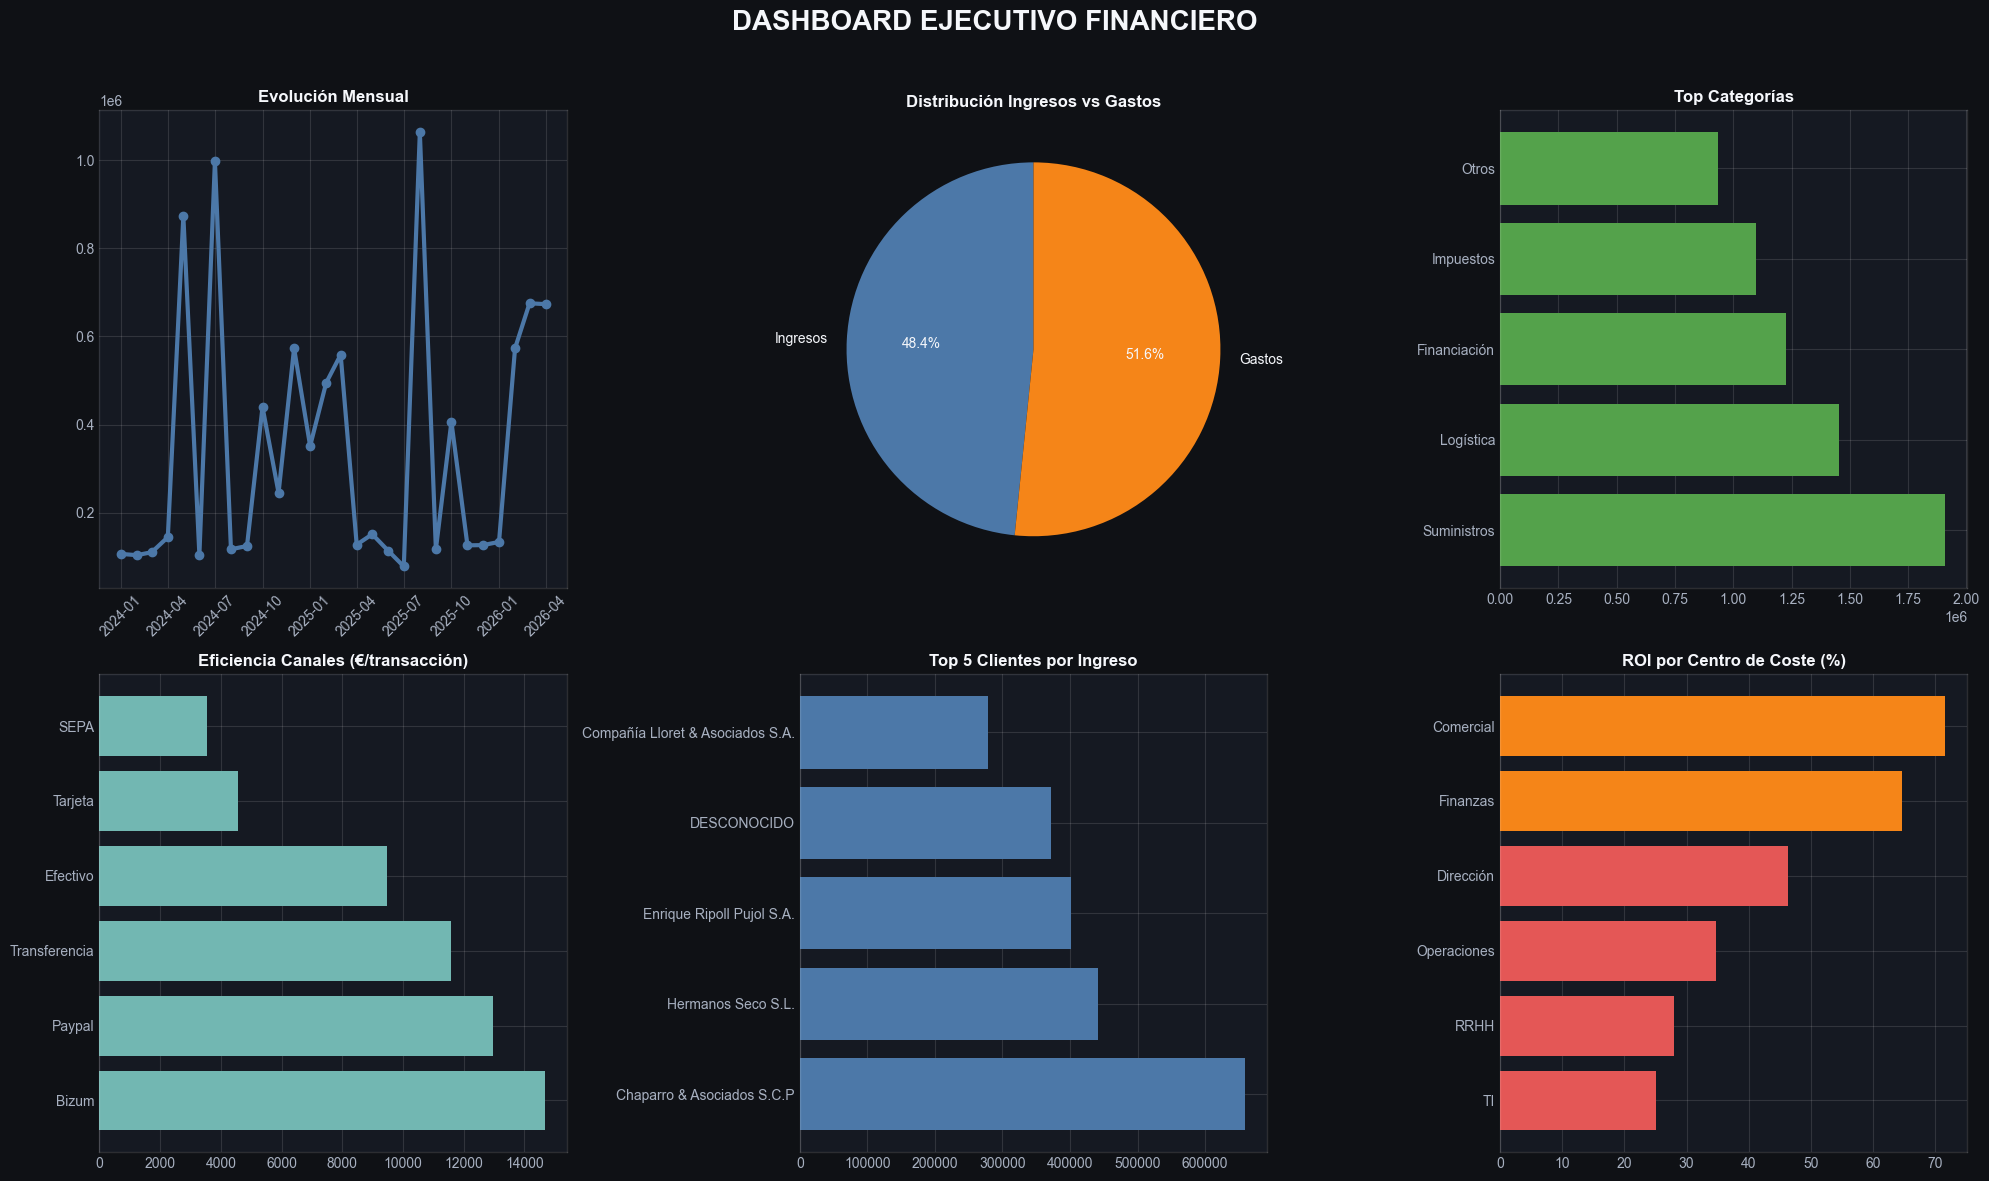

In [16]:
print("8. DASHBOARD VISUAL")

import matplotlib.pyplot as plt

plt.style.use("dark_background")

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle(
    "DASHBOARD EJECUTIVO FINANCIERO",
    fontsize=20,
    fontweight="bold",
    color="#F5F7FB",
    y=0.98
)

fig.patch.set_facecolor("#0f1115")

for ax in axes.flat:
    ax.set_facecolor("#151922")
    ax.tick_params(colors="#A7B0C0")
    ax.title.set_color("#F5F7FB")
    for spine in ax.spines.values():
        spine.set_color((1, 1, 1, 0.12))

axes[0, 0].plot(
    temporal["fecha_mes"],
    temporal["importe_limpio"],
    linewidth=3,
    marker="o",
    color="#4C78A8"
)
axes[0, 0].set_title("Evolución Mensual", fontweight="bold")
axes[0, 0].grid(True, alpha=0.15, color="white")
axes[0, 0].tick_params(axis="x", rotation=45)

axes[0, 1].pie(
    [ingresos, gastos],
    labels=["Ingresos", "Gastos"],
    autopct="%1.1f%%",
    colors=["#4C78A8", "#F58518"],
    startangle=90,
    textprops={"color": "#F5F7FB"}
)
axes[0, 1].set_title("Distribución Ingresos vs Gastos", fontweight="bold")

top_cat = pd.concat([cat_ing.head(5), cat_gas.head(5)], axis=0).groupby(level=0).sum().nlargest(5)
axes[0, 2].barh(top_cat.index, top_cat.values, color="#54A24B")
axes[0, 2].set_title("Top Categorías", fontweight="bold")

axes[1, 0].barh(canal_efic.index, canal_efic.values, color="#72B7B2")
axes[1, 0].set_title("Eficiencia Canales (€/transacción)", fontweight="bold")

axes[1, 1].barh(clientes_top.index, clientes_top.values, color="#4C78A8")
axes[1, 1].set_title("Top 5 Clientes por Ingreso", fontweight="bold")

roi_plot = centro_roi["ROI"].sort_values(ascending=True)
colors = ["#E45756" if x < 50 else "#F58518" if x < 100 else "#54A24B" for x in roi_plot]
axes[1, 2].barh(roi_plot.index, roi_plot.values, color=colors)
axes[1, 2].set_title("ROI por Centro de Coste (%)", fontweight="bold")

for ax in axes.flat:
    ax.grid(True, alpha=0.12, color="white")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(out / "dashboard_ejecutivo.png", dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()


**Descripción:**

- Se crea una figura con 6 paneles.
- El primer gráfico muestra evolución temporal.
- El segundo compara ingresos y gastos.
- El tercero resume categorías relevantes.
- El cuarto mide eficiencia de canales.
- El quinto muestra clientes top.
- El sexto muestra el ROI por centro de coste.
- ```plt.savefig(...)``` guarda el dashboard final.


### 10. Recomendaciones automáticas

Esta sección convierte los hallazgos en acciones de negocio.


In [10]:
print("9. RECOMENDACIONES ESTRATÉGICAS")

if canal_efic.iloc[0] > canal_efic.mean() * 1.5:
    print(f"Migrar parte del volumen hacia {canal_efic.index[0]}")

if roi_cat.iloc[0] > 70:
    print(f"Incrementar inversión en {roi_cat.index[0]}")

if top5_pct > 40:
    print(f"Riesgo de concentración: Top 5 clientes = {top5_pct:.1f}%")

if centro_roi['ROI'].min() < 50:
    peor_centro = centro_roi['ROI'].idxmin()
    print(f"Optimizar el centro de coste {peor_centro}")


9. RECOMENDACIONES ESTRATÉGICAS
Migrar parte del volumen hacia Bizum
Incrementar inversión en Marketing
Riesgo de concentración: Top 5 clientes = 45.8%
Optimizar el centro de coste TI


**Descripción:**

- Las condiciones generan recomendaciones según los resultados.
- Si un canal es mucho más eficiente que el promedio, se sugiere priorizarlo.
- Si la categoría más rentable es fuerte, se recomienda invertir más.
- Si el Top 5 clientes concentra demasiado ingreso, se alerta por riesgo.
- Si un centro de coste tiene ROI bajo, conviene revisarlo.


### 11. Exportar dashboard a HTML

En esta celda se genera un documento HTML ejecutivo que reúne el dashboard visual y una tabla con las métricas más importantes. El objetivo es dejar un archivo listo para compartir con dirección o subir a un entorno de presentación.

In [14]:
print("11. EXPORTACIÓN A HTML")

import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio

kpis = pd.DataFrame({
    "Métrica": [
        "Total Ingresos",
        "Total Gastos",
        "Saldo Neto",
        "Margen (%)",
        "Transacciones",
        "Pagadas (%)",
        "Categoría más rentable",
        "Canal más eficiente",
        "Cliente top",
        "Top 5 clientes (%)",
        "Mejor centro coste"
    ],
    "Valor": [
        f"€{ingresos:,.0f}",
        f"€{gastos:,.0f}",
        f"€{saldo:,.0f}",
        f"{margen:.1f}%",
        f"{len(df):,}",
        f"{pct_pagadas:.1f}%",
        roi_cat.index[0],
        canal_efic.index[0],
        ingresos_clientes.index[0],
        f"{top5_pct:.1f}%",
        centro_roi["ROI"].idxmax()
    ]
})

fig = make_subplots(
    rows=2,
    cols=3,
    specs=[
        [{"type": "scatter"}, {"type": "pie"}, {"type": "bar"}],
        [{"type": "bar"}, {"type": "bar"}, {"type": "bar"}]
    ],
    subplot_titles=(
        "Evolución Mensual",
        "Ingresos vs Gastos",
        "Top Categorías",
        "Eficiencia Canales (€/transacción)",
        "Top 5 Clientes por Ingreso",
        "ROI por Centro de Coste (%)"
    )
)

fig.add_trace(
    go.Scatter(
        x=temporal["fecha_mes"],
        y=temporal["importe_limpio"],
        mode="lines+markers",
        line=dict(width=3, color="#4C78A8"),
        fill="tozeroy",
        fillcolor="rgba(76, 120, 168, 0.18)",
        name="Evolución"
    ),
    row=1, col=1
)

fig.add_trace(
    go.Pie(
        labels=["Ingresos", "Gastos"],
        values=[ingresos, gastos],
        textinfo="label+percent",
        marker=dict(colors=["#4C78A8", "#F58518"])
    ),
    row=1, col=2
)

fig.add_trace(
    go.Bar(
        x=top_cat.values,
        y=top_cat.index,
        orientation="h",
        marker_color="#54A24B",
        name="Top Categorías",
        cliponaxis=False
    ),
    row=1, col=3
)

fig.add_trace(
    go.Bar(
        x=canal_efic.values,
        y=canal_efic.index,
        orientation="h",
        marker_color="#72B7B2",
        name="Canales",
        cliponaxis=False
    ),
    row=2, col=1
)

fig.add_trace(
    go.Bar(
        x=clientes_top.values,
        y=clientes_top.index,
        orientation="h",
        marker_color="#4C78A8",
        name="Clientes",
        cliponaxis=False
    ),
    row=2, col=2
)

fig.add_trace(
    go.Bar(
        x=roi_plot.values,
        y=roi_plot.index,
        orientation="h",
        marker_color="#ff9A2F",
        name="ROI",
        cliponaxis=False
    ),
    row=2, col=3
)

fig.update_layout(
    template="plotly_dark",
    height=950,
    showlegend=False,
    paper_bgcolor="rgba(0,0,0,0)",
    plot_bgcolor="rgba(0,0,0,0)",
    font=dict(color="#F5F7FB", family="Arial"),
    margin=dict(l=20, r=20, t=60, b=20),
    uniformtext_minsize=14,
    uniformtext_mode="hide"
)

fig.update_annotations(font=dict(color="#F5F7FB", size=13))

fig.update_xaxes(
    gridcolor="rgba(255,255,255,0.08)",
    zerolinecolor="rgba(255,255,255,0.12)",
    tickfont=dict(color="#A7B0C0")
)

fig.update_yaxes(
    gridcolor="rgba(255,255,255,0.06)",
    zerolinecolor="rgba(255,255,255,0.12)",
    tickfont=dict(color="#A7B0C0")
)

tabla_html = kpis.to_html(index=False, classes="table table-striped", border=0)

conclusiones_html = f"""
<ul>
    <li>La actividad se concentra en pocos segmentos y conviene priorizar los más rentables.</li>
    <li>El canal más eficiente debe tener mayor peso en la estrategia operativa.</li>
    <li>El riesgo de concentración en clientes debe revisarse si el Top 5 supera el umbral esperado.</li>
    <li>Los centros de coste con ROI bajo requieren revisión y posible ajuste de recursos.</li>
</ul>
"""

html_content = f"""
<!DOCTYPE html>
<html lang="es">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Dashboard Ejecutivo Financiero</title>
    <style>
        :root {{
            --bg: #0f1115;
            --bg-soft: #151922;
            --surface: #1a1f2b;
            --surface-2: #202635;
            --border: rgba(255, 255, 255, 0.08);
            --text: #f5f7fb;
            --muted: #a7b0c0;
            --accent: #0057ff;
            --accent-2: #3f7cff;
            --shadow: 0 18px 50px rgba(0, 0, 0, 0.32);
            --radius: 18px;
        }}

        * {{
            box-sizing: border-box;
        }}

        body {{
            margin: 0;
            padding: 32px;
            font-family: Arial, sans-serif;
            background:
                radial-gradient(circle at top right, rgba(0, 87, 255, 0.14), transparent 28%),
                radial-gradient(circle at bottom left, rgba(63, 124, 255, 0.08), transparent 24%),
                var(--bg);
            color: var(--text);
        }}

        .dashboard {{
            max-width: 1200px;
            margin: 0 auto;
            display: grid;
            gap: 24px;
        }}

        .header,
        .section {{
            background: linear-gradient(180deg, rgba(255,255,255,0.03), rgba(255,255,255,0.01)), var(--surface);
            border: 1px solid var(--border);
            border-radius: var(--radius);
            box-shadow: var(--shadow);
        }}

        .header {{
            padding: 26px;
        }}

        .header h1 {{
            margin: 0 0 8px;
            font-size: clamp(2rem, 4vw, 3rem);
            letter-spacing: -0.03em;
        }}

        .header p {{
            margin: 0;
            color: var(--muted);
            max-width: 72ch;
            line-height: 1.6;
        }}

        .section {{
            padding: 24px;
        }}

        .section h2 {{
            margin: 0 0 18px;
            font-size: 1.3rem;
            letter-spacing: -0.02em;
        }}

        .table-wrap {{
            overflow-x: auto;
            border-radius: 14px;
            border: 1px solid var(--border);
            background: var(--bg-soft);
        }}

        .table {{
            width: 100%;
            border-collapse: collapse;
            min-width: 700px;
        }}

        .table th,
        .table td {{
            padding: 14px 16px;
            text-align: left;
            border-bottom: 1px solid rgba(255, 255, 255, 0.06);
        }}

        .table th {{
            background: rgba(0, 87, 255, 0.14);
            color: var(--text);
            font-weight: 700;
            letter-spacing: 0.02em;
        }}

        .table td {{
            color: #d9e1f2;
            background: rgba(255, 255, 255, 0.01);
        }}

        .table tr:nth-child(even) td {{
            background: rgba(255, 255, 255, 0.03);
        }}

        .table tr:hover td {{
            background: rgba(0, 87, 255, 0.08);
        }}

        .section p,
        li {{
            color: var(--muted);
            line-height: 1.7;
        }}

        .section ul {{
            margin: 0;
            padding-left: 20px;
        }}

        .plotly-container {{
            border-radius: 14px;
            overflow: hidden;
            border: 1px solid var(--border);
            background: var(--bg-soft);
            padding: 8px;
        }}

        .section img {{
            max-width: 100%;
            border-radius: 14px;
        }}

        @media (max-width: 700px) {{
            body {{
                padding: 16px;
            }}

            .header,
            .section {{
                padding: 18px;
            }}
        }}
    </style>
</head>
<body>
    <div class="dashboard">
        <div class="header">
            <h1>Dashboard Ejecutivo Financiero</h1>
            <p>Resumen de resultados, eficiencia, concentración y focos estratégicos del negocio.</p>
        </div>

        <div class="section">
            <h2>KPIs recomendados</h2>
            <div class="table-wrap">
                {tabla_html}
            </div>
        </div>

        <div class="section">
            <h2>Visualización interactiva</h2>
            <div class="plotly-container">
                {fig.to_html(full_html=False, include_plotlyjs='cdn')}
            </div>
        </div>

        <div class="section">
            <h2>Conclusiones clave</h2>
            {conclusiones_html}
        </div>
    </div>
</body>
</html>
"""

html_file = out / "dashboard_ejecutivo.html"
with open(html_file, "w", encoding="utf-8") as f:
    f.write(html_content)

print(f"Archivo generado: {html_file}")


11. EXPORTACIÓN A HTML
Archivo generado: output\dashboard_ejecutivo.html


**Descripción:**

- ```to_html(...)``` convierte la tabla de KPIs en una tabla HTML lista para incrustar en el documento.
- ```make_subplots(...)``` crea la estructura del dashboard con varias gráficas en una sola figura.
- ```go.Scatter(...)``` dibuja la evolución mensual como línea.
- ```go.Pie(...)``` construye el gráfico circular de ingresos vs gastos.
- ```go.Bar(...)``` crea las barras horizontales de categorías, canales, clientes y ROI.
- ```add_trace(...)``` inserta cada gráfico dentro de su celda correspondiente.
- ```update_layout(...)``` configura el título, el estilo general y la apariencia del dashboard.
- ```update_xaxes(...)``` y ```update_yaxes(...)``` asignan nombres a los ejes.
- ```fig.to_html(...)``` convierte el dashboard interactivo en código HTML para incrustarlo en el reporte.
- ```open(..., "w", encoding="utf-8")``` abre el archivo HTML para escritura.
- ```f.write(...)``` guarda el contenido final del documento.

**Métricas incluidas**

- Estas métricas están pensadas para un dashboard ejecutivo y conectan con los insights del análisis.
- Total Ingresos.
- Total Gastos.
- Saldo Neto.
- Margen (%).
- Transacciones.
- Pagadas (%).
- Categoría más rentable.
- Canal más eficiente.
- Cliente con más ingresos.
- Centro de coste con mejor ROI.

**Nota técnica**

Para exportar gráficos interactivos en HTML, Plotly recomienda usar write_html() o to_html() dentro de una plantilla HTML, porque permite abrir el resultado en cualquier navegador. Para tablas, DataFrame.to_html() es el método estándar de pandas para convertir un resumen en formato web.